# Analyzing Eigenmode Dataset

In [1]:
import numpy as np
import os

DATASET_DIR = "dataset"
N_SAMPLES = 1000

def load_csv(path):
    return np.loadtxt(path, delimiter=",")

def load_sample(sample_dir):
    """
    Load the first eigenmode and Gaussian propagation fields from a sample directory.
    Returns a dict with real and imaginary parts kept separate:
      - 'eigenmode_real': array of shape (H, W)
      - 'eigenmode_imag': array of shape (H, W)
      - 'gaussian_forward_real': array of shape (H, W)
      - 'gaussian_forward_imag': array of shape (H, W)
      - 'gaussian_reversed_real': array of shape (H, W)
      - 'gaussian_reversed_imag': array of shape (H, W)
    """
    return {
        "eigenmode_real":         load_csv(os.path.join(sample_dir, "eigenmode_001_real.csv")),
        "eigenmode_imag":         load_csv(os.path.join(sample_dir, "eigenmode_001_imag.csv")),
        "gaussian_forward_real":  load_csv(os.path.join(sample_dir, "gaussian_prop_forward_real.csv")),
        "gaussian_forward_imag":  load_csv(os.path.join(sample_dir, "gaussian_prop_forward_imag.csv")),
        "gaussian_reversed_real": load_csv(os.path.join(sample_dir, "gaussian_prop_reversed_real.csv")),
        "gaussian_reversed_imag": load_csv(os.path.join(sample_dir, "gaussian_prop_reversed_imag.csv")),
    }

# Load all 1000 samples
sample_dirs = sorted([
    os.path.join(DATASET_DIR, d)
    for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])[:N_SAMPLES]

dataset = [load_sample(d) for d in sample_dirs]

print(f"Loaded {len(dataset)} samples")
print(f"Eigenmode real shape : {dataset[0]['eigenmode_real'].shape}")
print(f"Eigenmode imag shape : {dataset[0]['eigenmode_imag'].shape}")

Loaded 1000 samples
Eigenmode real shape : (64, 64)
Eigenmode imag shape : (64, 64)


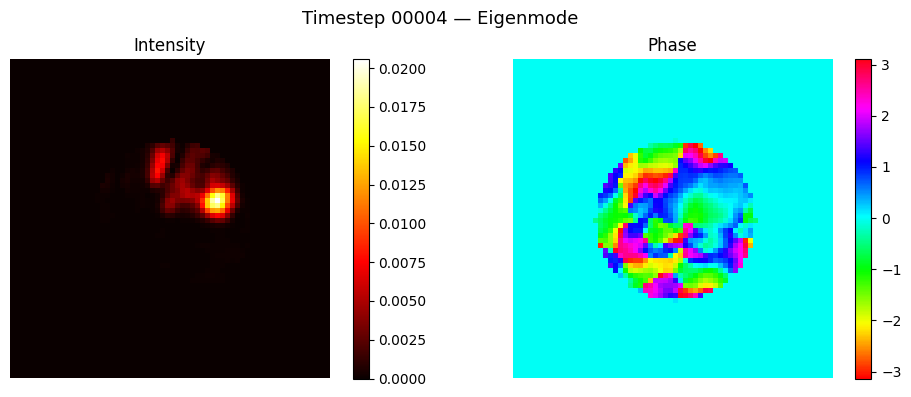

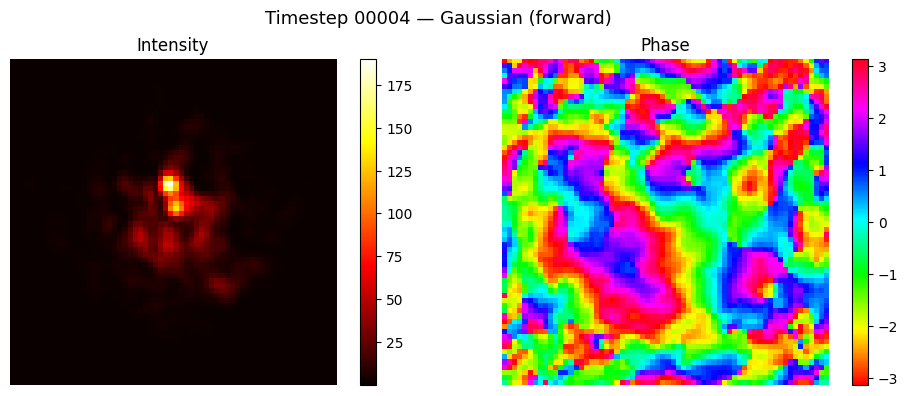

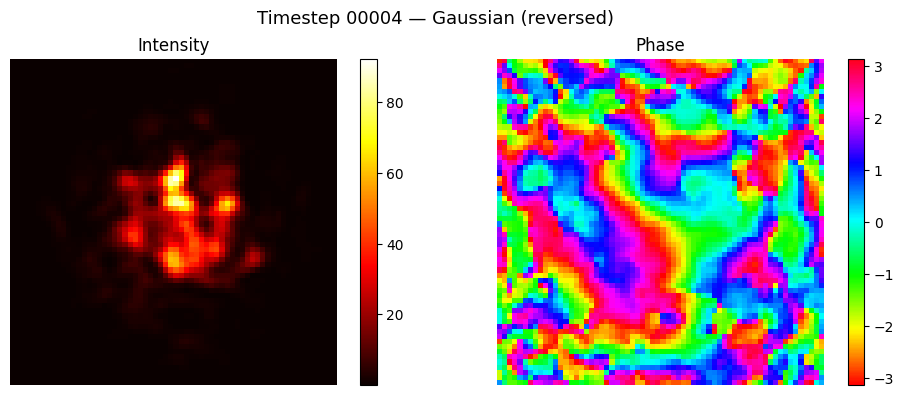

In [5]:
import matplotlib.pyplot as plt

def TotInt(Ex, title="", phase=True, cmappy='hot', enable_colourbar=True):
    """Plot intensity (and optionally phase) of a complex 2D field."""
    if not phase:
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
        if title:
            ax.set_title(title)
        im = ax.imshow(np.abs(Ex)**2, cmap=cmappy)
        ax.axis('off')
        if enable_colourbar:
            fig.colorbar(im, ax=ax)
    else:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        if title:
            fig.suptitle(title, fontsize=13)
        axes[0].set_title('Intensity')
        im0 = axes[0].imshow(np.abs(Ex)**2, cmap=cmappy)
        axes[0].axis('off')
        fig.colorbar(im0, ax=axes[0])

        axes[1].set_title('Phase')
        im1 = axes[1].imshow(np.angle(Ex), cmap='hsv', interpolation='nearest')
        axes[1].axis('off')
        if enable_colourbar:
            fig.colorbar(im1, ax=axes[1])
    plt.tight_layout()
    plt.show()


# ── Select a timestep to inspect ──────────────────────────────────────────────
timestep = 3   # ← change this index (0-based) to inspect a different sample

sample = dataset[timestep]
sample_label = f"Timestep {timestep + 1:05d}"

# Reconstruct complex fields
eigenmode         = sample["eigenmode_real"]         + 1j * sample["eigenmode_imag"]
gaussian_forward  = sample["gaussian_forward_real"]  + 1j * sample["gaussian_forward_imag"]
gaussian_reversed = sample["gaussian_reversed_real"] + 1j * sample["gaussian_reversed_imag"]

# ── Plot ───────────────────────────────────────────────────────────────────────
TotInt(eigenmode,         title=f"{sample_label} — Eigenmode")
TotInt(gaussian_forward,  title=f"{sample_label} — Gaussian (forward)")
TotInt(gaussian_reversed, title=f"{sample_label} — Gaussian (reversed)")
